In [1]:
import os
import sys
import numpy as np
import matplotlib.pyplot as plt
import ROOT as root
from ROOT import TH2F
from ROOT import TH1F
from openpyxl import Workbook
import pytz
from datetime import datetime
import json
from ROOT import TCanvas
import statistics
import pandas as pd
#%jsroot on

Welcome to JupyROOT 6.30/04


In [2]:
def get_leakage_cat(filepath, target_component):
    """
    Apre un file JSON, cerca un blocco tramite il valore del campo 'component'
    e restituisce il valore associato a 'breakdown_voltage_V'.
    
    :param filepath: Str, percorso del file JSON da aprire
    :param target_component: Str, l'ID del componente da cercare (es. "PRE01000000000000010110")
    :return: Float, il valore di breakdown_voltage_V se trovato, altrimenti None
    """
    try:
        # Apre e carica il file JSON
        with open(filepath, 'r', encoding='utf-8') as file:
            data = json.load(file)
        
        # Se il JSON è una lista di blocchi (struttura standard)
        if isinstance(data, list):
            for block in data:
                if block.get('component') == target_component:
                    return block.get('category')
                    
        # Se il JSON è un singolo dizionario/blocco
        elif isinstance(data, dict):
            if data.get('component') == target_component:
                return data.get('category')
        
        # Se il ciclo finisce e il componente non è stato trovato
        print(f"Componente '{target_component}' non trovato nel file.")
        return None

    except FileNotFoundError:
        print(f"Errore: Il file '{filepath}' non esiste.")
        return None
    except json.JSONDecodeError:
        print(f"Errore: Il file '{filepath}' non contiene un JSON valido.")
        return None

# --- Esempio di utilizzo ---
# v_breakdown = get_breakdown_voltage("misure_sensori.json", "PRE01000000000000010110")
# print(f"Tensione di breakdown: {v_breakdown} V")

In [3]:
root.gStyle.SetOptStat(0)
#root.gStyle.SetOptStat(1111)
#root.gStyle.SetOptFit(101)
palette = np.array([3,5,2], dtype=np.int32)
  
  
root.gStyle.SetTitleOffset( 1.3, "z" )
root.gStyle.SetLabelOffset( 0., "z" )
#root.gStyle.SetTitleSize(0.06,"z") 
root.gStyle.SetLabelSize(0.035,"z")
root.gStyle.SetPaintTextFormat("1.3f")

   
###################################/ 
## THIS SCRIPT ASSUMES raw voltages in [V] and raw currents in [A] #
## Parameters below are in [V] and [uA]                            #
###################################/


# The two parameters below not needed: current is measured 10V before the VBD of the specific sensor; no point in defining a constant Vmaxop as VBD (slightly) changes sensor-to-sensor
#V_current_level = 215,215,215,215,215,215,215,215,215,215 #Leakage current measured at this V  (LC2)
#V_current_level = 235.,235.,355.,290.,275.,230.,205.,185.,120.,160.,180.,150.,150.,150.,150. #Leakage current measured at this V  (LC1)
#V_current_monitor = V_current_level #Voltage up to which the current level is monitored

#VBD_expected = 240
#VBD_expected_sigma = 10
VBD_expected = 239.5
VBD_expected_sigma = 6
V_min_kfactor = 100.  #k-factor not used to calculate VBD if VBD<V_min_kfactor
I_thr = 30. #sensor discarded if I > I_thr [uA] in the voltage operation range [ 0-V_current_monitor ]
I_compliance = 1000 # VBD calculation begins when I < I_compliance  [uA]
I_compliance_minimum = 50 # [uA] VBD calculation performed only if compliance was set above this threshold
k_thr = 20. # 20  k value to define VBD using k-factor method
current_conversion_value = 1E9 # conversion from [A] (raw data) to [uA] (used in the final plots)
temperature_conversion = True # set to True if you want to scale the current to a certain temperature
temperature_conversion_factor = 1.22 # factor to scale the current
start_bd_calculation = 5 #BD calculation start from this sampled bias point: avoid considering the very first voltages of the bias sweep 
low_iv_range = 10  #low and high ranges for I@100V plot [uA]
high_iv_range = 50
low_vbd_range = 210 #low and high ranges for VBD plot [V]
high_vbd_range = 270
n_wafer = 13 #
n_row = 7 #
n_col = 8 # 
start_wafer = 14 #first wafer number in the dataset
start_row = 1 #the first row of the wafer to be measured
start_col = 1 #the first column of the wafer to be measured 
bcurrent = False
bvoltage = False
bcategory = True
bnoisy = False
save = True
verbose = True
write_json = True  #produces the json file needed to upload the tests to the ETL database

dtz = datetime(2026, 7, 27, 12, 0, 0)
dtz = dtz.replace(tzinfo=pytz.utc)
dtz.astimezone(pytz.timezone("Europe/Rome"))

user = "fsiviero" # cern user of who's uploading the test
location = "Torino" # where the test was performed

if(bcategory): 
    root.gStyle.SetPalette(3,palette) # custom palette used for Categories

if(bvoltage):
    #root.gStyle.SetPalette("Black Body") # palette for VBD
    root.gStyle.SetPalette(70) # palette for VBD

if(bcurrent or bnoisy):
    #root.gStyle.SetPalette("Black Body") # palette for I@V_current_level
    root.gStyle.SetPalette(70)
    root.TColor.InvertPalette()

invert_polarity=False

file_qa = root.TFile.Open("/Users/icosivi/Desktop/PRE-SERIE/PRE-SERIE_FBK_Torino_16x16_IV_290meas.root")
tree_qa = file_qa.Get("Tree")

file_v = root.TFile.Open("/Users/icosivi/Desktop/PRE-SERIE/PRE-SERIE_FBK_Vendor_16x16_IV_GR.root")
tree_v = file_v.Get("Tree")
  
counter_qa = 0
I_qa_100V = 0.
VBD_qa_u = 0.
VBD_qa_d = 0.
k_qa_u = []
k_qa_d = []
k_qa_u.append(0.)
k_qa_u.append(0.)
k_qa_d.append(0.)
k_qa_d.append(0.)

tests_json = []
optical_inspection_json = []

current_levels_counter=[0,0,0,0,0,0]
vcount_vbd_qa = [[[0 for i in range(n_row)] for j in range(n_col)] for k in range(n_wafer)]
temperature = [[[0 for i in range(n_row)] for j in range(n_col)] for k in range(n_wafer)]
medium = [[[0 for i in range(n_row)] for j in range(n_col)] for k in range(n_wafer)]
vcount_i_qa = [[[0 for i in range(n_row)] for j in range(n_col)] for k in range(n_wafer)]
vcount_bump_qa = [[[0 for i in range(n_row)] for j in range(n_col)] for k in range(n_wafer)]
vvbd_qa = [[[0 for i in range(n_row)] for j in range(n_col)] for k in range(n_wafer)]
vvbd_good = [[[] for i in range(n_row)] for j in range(n_col)]
vi_good = [[[] for i in range(n_row)] for j in range(n_col)]
vi_qa = [[[0 for i in range(n_row)] for j in range(n_col)] for k in range(n_wafer)]
vbump_qa = [[[0 for i in range(n_row)] for j in range(n_col)] for k in range(n_wafer)]
vi_raw = [[[[] for i in range(n_row)] for j in range(n_col)] for k in range(n_wafer)]
v_raw = [[[[] for i in range(n_row)] for j in range(n_col)] for k in range(n_wafer)]
vvbd_by_col = [0 for i in range(n_col)]
vvbd_by_col_norm = [0 for i in range(n_col)]
hI_qa_100V = []
hdeltaI_qa_100V = []
hV_qa = []
hdeltaV_qa = []
hbump_qa = []
hnoisy_qa = []
hcount_qa = []
min_I = []

#himax = TH1F( "stats", r"IGR (diced)", 10000, 0, 1 )
himax = TH2F( "stats", r"IGR (diced)", n_col,start_col,(start_col+n_col),n_row,start_row,(start_row+n_row) )
#himax_v = TH1F( "stats_v", r"IGR (on-wafer)", 10000, 0, 1 )
himax_v = TH2F( "stats_v", r"IGR (diced)", n_col,start_col,(start_col+n_col),n_row,start_row,(start_row+n_row) )
hvmax = TH1F( "vbd_stats", r"V_{bd} (GOOD sensors only)", 50, 200, 300 )
hdelta_imax = TH1F( "d stats", r" Delta I@V_{MaxOp}", 20, -10, 10 )
hdelta_vmax = TH1F( "d vbd_stats", r" Delta V_{bd}", 40, -20, 20)
hiMax = []

hi_total = TH2F( "I_qa_V_all_W", r"I@V_{MaxOp} on-wafer - all wafers (average of GOOD sensors)", n_col,start_col,(start_col+n_col),n_row,start_row,(start_row+n_row) )
hv_total = TH2F( "V_qa_all_W", "VBD on-wafer - all wafers (average of GOOD sensors)", n_col,start_col,(start_col+n_col),n_row,start_row,(start_row+n_row) )
hbump_total = TH2F( "bump_qa_all_W", "Fraction of GOOD sensors - all 11 wafers", n_col,start_col,(start_col+n_col),n_row,start_row,(start_row+n_row))
hi_total_norm = TH2F( "I_qa_V_all_W_norm", r"I@V_{MaxOp} on-wafer - all wafers", n_col,start_col,(start_col+n_col),n_row,start_row,(start_row+n_row) )
hv_total_norm = TH2F( "V_qa_all_W_norm", "VBD on-wafer - all wafers", n_col,start_col,(start_col+n_col),n_row,start_row,(start_row+n_row) )

hdeltaV_qa_all_wafer = TH2F( "V_delta_qa_allW", "Delta VBD all Wafers", n_col,start_col,(start_col+n_col),n_row,start_row,(start_row+n_row) )
hdeltaI_qa_100V_all_wafer = TH2F( "I_delta_qa_V_allW", r"Delta I@V_{MaxOp} all Wafers", n_col,start_col,(start_col+n_col),n_row,start_row,(start_row+n_row) )

hdeltaV_qa_all_wafer_norm = TH2F( "V_delta_qa_allW_norm", "Delta VBD all Wafers", n_col,start_col,(start_col+n_col),n_row,start_row,(start_row+n_row) )
hdeltaI_qa_100V_all_wafer_norm = TH2F( "I_delta_qa_V_allW_norm", r"Delta I@V_{MaxOp} all Wafers", n_col,start_col,(start_col+n_col),n_row,start_row,(start_row+n_row) )


for i in range(n_wafer):
    #hI_qa_100V.append( TH2F( "I_qa_"+str(V_current_level[i])+"V_W"+str(i+1), "I@"+str(V_current_level[i])+"V on-wafer W"+str(i+1), n_col,start_col,(start_col+n_col),n_row,start_row,(start_row+n_row) ) )
    hI_qa_100V.append( TH2F( "I_qa_V_W"+str(i+start_wafer), r"I@V_{MaxOp} on-wafer W"+str(i+start_wafer), n_col,start_col,(start_col+n_col),n_row,start_row,(start_row+n_row) ) )
    hV_qa.append( TH2F( "V_qa_W"+str(i+start_wafer), "VBD on-wafer W"+str(i+start_wafer), n_col,start_col,(start_col+n_col),n_row,start_row,(start_row+n_row) ) )
    hdeltaV_qa.append( TH2F( "V_delta_qa_W"+str(i+start_wafer), "Delta VBD on-wafer W"+str(i+start_wafer), n_col,start_col,(start_col+n_col),n_row,start_row,(start_row+n_row) ) )
    hdeltaI_qa_100V.append( TH2F( "I_delta_qa_V_W"+str(i+start_wafer), r"Delta I@V_{MaxOp} on-wafer W"+str(i+start_wafer), n_col,start_col,(start_col+n_col),n_row,start_row,(start_row+n_row) ) )
    min_I.append(1000)

    hbump_qa.append( TH2F( "bump_qa_W"+str(i+start_wafer), "Categories on-wafer W"+str(i+start_wafer), n_col,start_col,(start_col+n_col),n_row,start_row,(start_row+n_row)) )
    hnoisy_qa.append( TH2F( "noisy_qa_W"+str(i+start_wafer), "Bad pads on-wafer W"+str(i+start_wafer), n_col,start_col,(start_col+n_col),n_row,start_row,(start_row+n_row)) )

dumb_counter= 0. # Total number of sensors/measurements in the root file
non_empty_counter= 0. # Sensors with both I and V arrays having size !=0 (the sensor was in fact measured)
non_zero_counter= 0. # Sensors with both I and V arrays having values !=0 (the sensor was measured and can be bias
hpk_counter=0. # Sensors identified by hpk as medium
total_sensors_counter_qa= 0. #Fraction of sensors whose category can be properly defined
good_sensors_counter_qa= 0. #Fraction of GOOD sensors
bad_sensors_counter_qa= 0. #Fraction of BAD sensors
medium_sensors_counter_qa= 0. #Fraction of MEDIUM sensors
medium_but_good_counter=0. # Sensors identified by hpk as medium, but GOOD with our analysis
iv_quality = bool() # Boolean reflecting the quality of the IV curve: sensor is BAD whenever iv_quality is set to False

wb = pd.read_excel('/Users/icosivi/Desktop/PRE-SERIE/FBK/FBK_16x16_PRE-SERIES.xlsx') # excel that maps 'serial number --> vendor, batch, wafer, row, column'

if(write_json):
    json_filename="FBK_16x16_PRE-SERIES_Torino_IV"
    
save_path = '/Users/icosivi/Desktop/PRE-SERIE/FBK/'

In [4]:
for event in tree_qa:
 if event.wafer==24:  
  #if get_leakage_cat(save_path+"FBK_16x16_PRE-SERIES_Torino_IV.json", str(wb[(wb['Wafer'] == event.wafer) & (wb['Row'] == event.row) & (wb['Column'] == event.column)]['SerialNumber'].iloc[0])) == 'BAD':
    IGR = [float(i)*(1/temperature_conversion_factor)*current_conversion_value for i in event.IGR]
    himax.Fill(event.column,event.row,IGR[-5])
    
for event in tree_v:
 if event.wafer==24:
  #if get_leakage_cat(save_path+"FBK_16x16_PRE-SERIES_Torino_IV.json", str(wb[(wb['Wafer'] == event.wafer) & (wb['Row'] == event.row) & (wb['Column'] == event.column)]['SerialNumber'].iloc[0])) == 'BAD':
    IGR_v = [i*current_conversion_value for i in event.I_GR]
    himax_v.Fill(event.column,event.row,IGR_v[-5])

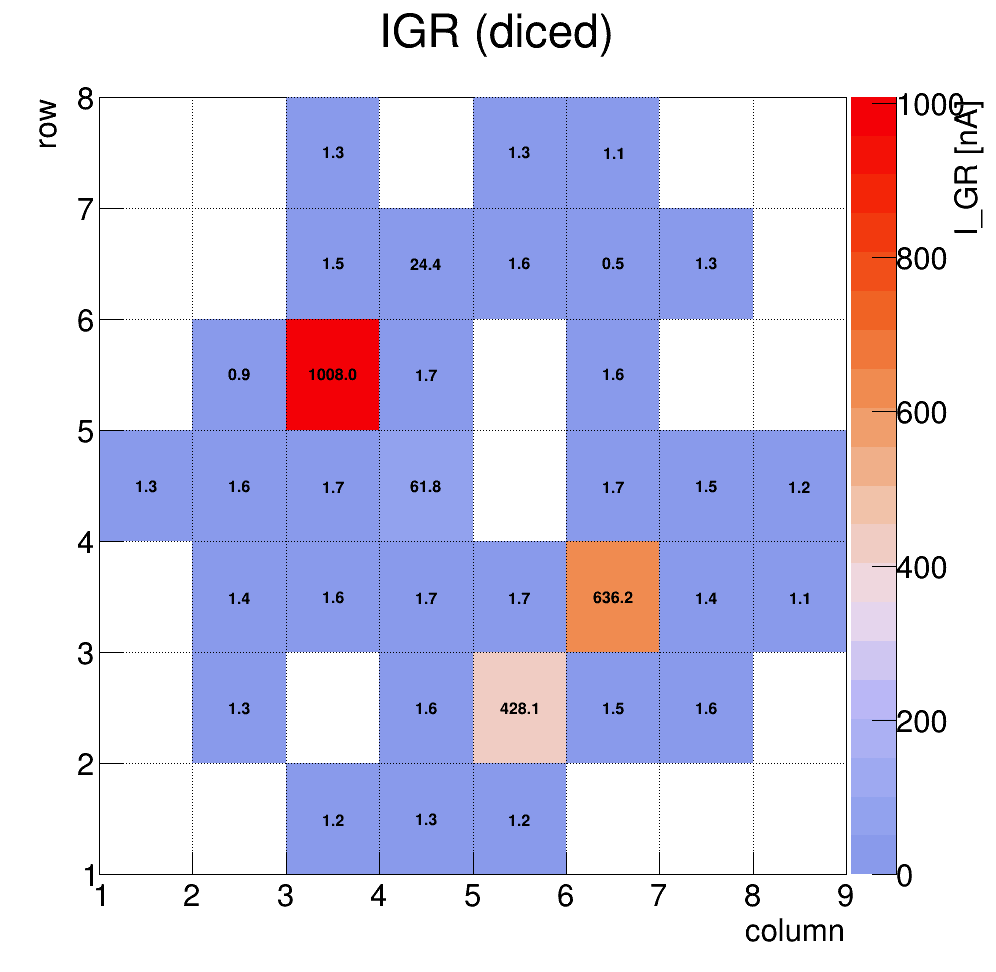

In [5]:
root.gStyle.SetPalette(70)
root.TColor.InvertPalette()
cV_total = root.TCanvas("c_V_all_W", "VBD all W", 1000,1000)

#himax.GetZaxis().SetRangeUser( low_vbd_range, high_vbd_range )
himax.GetZaxis().SetTitle(r"I_GR [nA]")
himax.GetXaxis().SetTitle("column") 
himax.GetYaxis().SetTitle("row")
himax.SetMarkerSize(3.)

root.gStyle.SetPaintTextFormat("1.1f")
cV_total.SetRightMargin(0.15)
cV_total.cd()
himax.SetMarkerSize(0.9)
himax.Draw("textcolz")
#hV_qa[i].SaveAs(save_path+"VBD_W"+str(i+1)+".root")
root.gPad.SetGrid(1,1)
root.gPad.Update()
cV_total.Update()
himax.GetXaxis().SetNdivisions(n_col)
himax.GetYaxis().SetNdivisions(n_row)

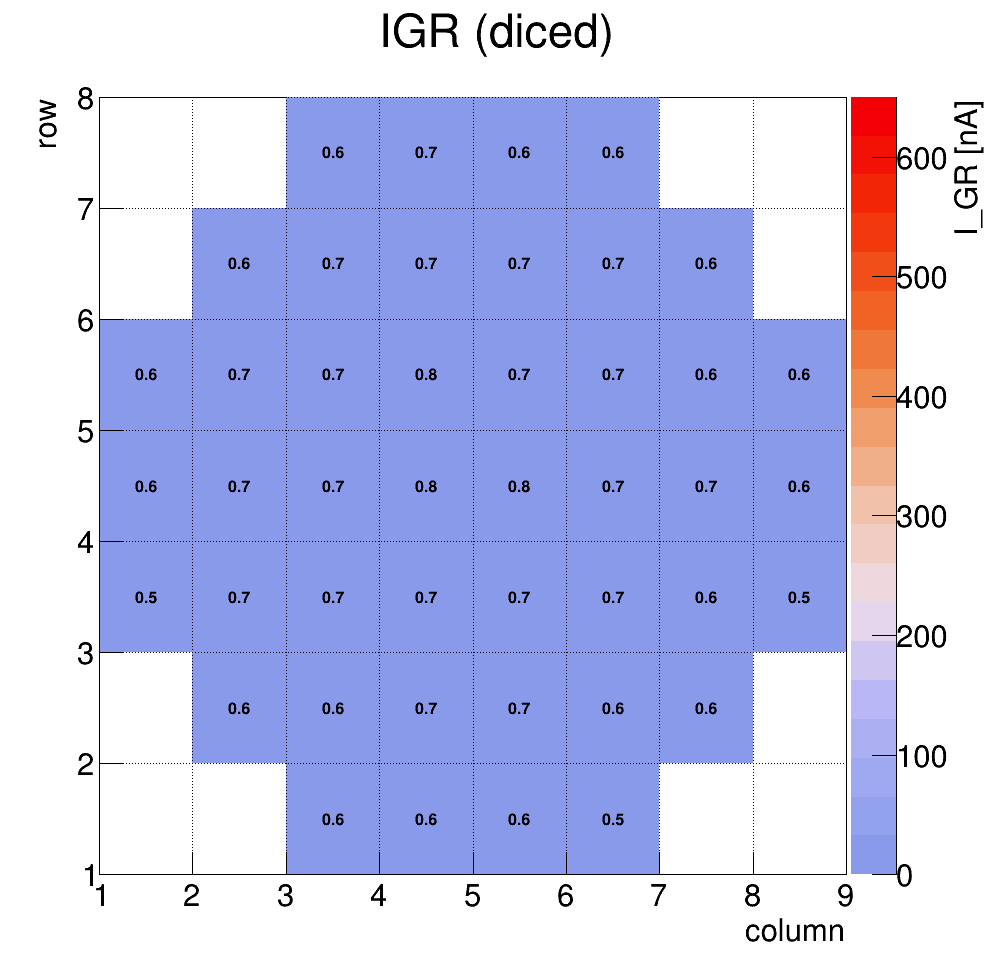

In [6]:
#root.gStyle.SetPalette(70)
#root.TColor.InvertPalette()
cV_total_v = root.TCanvas("c_V_all_W_v", "VBD all W", 1000,1000)

himax_v.GetZaxis().SetRangeUser( 0, 650 )
himax_v.GetZaxis().SetTitle(r"I_GR [nA]")
himax_v.GetXaxis().SetTitle("column") 
himax_v.GetYaxis().SetTitle("row")
himax_v.SetMarkerSize(3.)

root.gStyle.SetPaintTextFormat("1.1f")
cV_total_v.SetRightMargin(0.15)
cV_total_v.cd()
himax_v.SetMarkerSize(0.9)
himax_v.Draw("textcolz")
#hV_qa[i].SaveAs(save_path+"VBD_W"+str(i+1)+".root")
root.gPad.SetGrid(1,1)
root.gPad.Update()
cV_total_v.Update()
himax_v.GetXaxis().SetNdivisions(n_col)
himax_v.GetYaxis().SetNdivisions(n_row)

In [ ]:
from ROOT import TCanvas
import statistics

root.gStyle.SetOptFit(111)       
cxd = TCanvas( "c_vbdd", "c_vbdd", 900,900)
cxd.cd()
cxd.SetLogy(1)
cxd.SetLogx(1)
#gaus_func1_delta = root.TF1("gaus_vbdd", "gaus", -20, 20)
himax.GetXaxis().SetTitle(r"I_GR [uA]")
himax.GetXaxis().SetTitleOffset(1.3)
himax.SetLineWidth(2)
himax.Draw()
himax_v.Draw("sames")
himax_v.SetLineWidth(2)
himax.SetLineColor(2)
#hdelta_vmax.Fit(gaus_func1_delta,'R')
root.gPad.SetGrid(1,1)
root.gPad.Draw()
cxd.Modified()
cxd.Update()

In [ ]:
for event in tree_qa:
    dumb_counter+=1
    if(int(event.I_GR.size())>=start_bd_calculation and int(event.V.size())>=start_bd_calculation ):
      non_empty_counter+=1

      if( event.I_GR.at(event.I_GR.size()-1)<0 ): 
        Iback = [abs(i) for i in event.I_GR]
        #Iback = [float(-i) for i in event.I_GR]
        for idx, i in enumerate(event.I_GR):  
          if(idx<=event.V.size()-1):
           vi_raw[event.wafer-start_wafer][event.column-start_col][event.row-start_row].append(float(-i))  
        #if(verbose): 
          #print("Sensor from wafer "+str(event.wafer)+" row "+str(event.row)+" column "+str(event.column)+" with negative current detected. Changing polarity.")
      else:
        Iback = [abs(i) for i in event.I_GR]
        #Iback = [i for i in event.I_GR]
        for idx, i in enumerate(event.I_GR):  
          if(idx<=event.V.size()-1):
           vi_raw[event.wafer-start_wafer][event.column-start_col][event.row-start_row].append(float(i))  

      if( event.V.at(event.V.size()-1)<0 ): 
        Vbias = [-i for i in event.V]  
        for idx, i in enumerate(event.V):  
         if(idx<=event.I_GR.size()-1):
           v_raw[event.wafer-start_wafer][event.column-start_col][event.row-start_row].append(float(-i))        
        #if(verbose): 
          #print("Sensor from wafer "+str(event.wafer)+" row "+str(event.row)+" column "+str(event.column)+" with negative Voltage detected. Changing polarity.")
      else:
        Vbias = [i for i in event.V]
        for idx, i in enumerate(event.V): 
          if(idx<=event.I_GR.size()-1): 
           v_raw[event.wafer-start_wafer][event.column-start_col][event.row-start_row].append(float(i))
           

      non_zero_current = sum(Iback) 
      non_zero_voltage = sum(Vbias)


      if(non_zero_voltage!=0 and non_zero_current!=0):
        non_zero_counter+=1
    
        iv_quality = True
        I_qa_100V = -1000
        
        type_counter = 0
        type_counter_I_qa = 0
              
        ####### I@V_current_level calculation #####
        for i in range(len(Iback)):
          if( i!=0 and Vbias[i-1]<(Vbias[len(Iback)-1]-10) and Vbias[i]>=(Vbias[len(Iback)-1]-10) ):
            if( Vbias[i]==Vbias[len(Iback)-1]-10 ): 
              I_qa_100V = Iback[i]
            else: 
              I_qa_100V = (((Iback[i]-Iback[i-1]))/(Vbias[i]-Vbias[i-1]))*((Vbias[len(Iback)-1]-10)-Vbias[i]) + Iback[i]
            break
            
        
        I_qa_100V = current_conversion_value*I_qa_100V
        #print(I_qa_100V)
        #print(" ")
        
        if( I_qa_100V<0. ): 
          iv_quality=False
          
  
        if(I_qa_100V>=0):
          vi_qa[event.wafer-start_wafer][event.column-start_col][event.row-start_row] += I_qa_100V
          vcount_i_qa[event.wafer-start_wafer][event.column-start_col][event.row-start_row] += 1
          hiMax.append(float(I_qa_100V))    
      else:
        if(verbose):
          print("Sensor from wafer "+str(event.wafer)+" row "+str(event.row)+" column "+str(event.column)+" has Voltage and/or Current always equal to zero. PLEASE CHECK.")
    else:
      if(verbose):
        print("Sensor from wafer "+str(event.wafer)+" row "+str(event.row)+" column "+str(event.column)+": Voltage and/or Current vectors have less than "+str(start_bd_calculation)+" elements. PLEASE CHECK.")

In [ ]:
import statistics

print(statistics.mean(hiMax))
print(statistics.stdev(hiMax))

In [ ]:
serial_num_counter=0

for i in range(n_wafer):
    for j in range(n_col):
        for k in range(n_row):
          #if( i==0 ):
          if( i<20 ):
             if(vcount_i_qa[i][j][k]!=0): 
               hI_qa_100V[i].Fill( j+start_col, k+start_row, vi_qa[i][j][k]/vcount_i_qa[i][j][k] )

In [ ]:
root.gStyle.SetPalette(70)
root.TColor.InvertPalette()
cI_100V = []

for i in range(n_wafer):
    cI_100V.append(root.TCanvas("c_I_V_W"+str(i+start_wafer), r"c I@V_{MaxOp} ETL site W"+str(i+start_wafer), 1000,1000))


for i in range(n_wafer):
 #if( i==0 ):
 if( i<20 ):
    #hI_qa_100V[i]->GetZaxis()->SetRangeUser( 0.1, hI_qa_100V[i]->GetMaximum() ) #Alternative colored axis range
    hI_qa_100V[i].GetZaxis().SetRangeUser( low_iv_range, high_iv_range )
    hI_qa_100V[i].GetZaxis().SetTitle("[uA]")
    hI_qa_100V[i].GetXaxis().SetTitle("column")
    hI_qa_100V[i].GetYaxis().SetTitle("row")
    hI_qa_100V[i].SetMarkerSize(3.)

    #cI_100V.append(root.TCanvas("c_I_"+str(V_current_level)+"V_W"+str(i+1), "c I@"+str(V_current_level)+"V_W"+str(i+1), 1000,1000))
    cI_100V[i].SetRightMargin(0.15)
    cI_100V[i].cd()
    hI_qa_100V[i].SetMarkerSize(0.9)
    hI_qa_100V[i].Draw("textcolz")
    root.gPad.SetGrid(1,1)
    root.gPad.SetLogz(1)
    root.gPad.Update()
    cI_100V[i].Update()
    hI_qa_100V[i].GetXaxis().SetNdivisions(n_col)
    hI_qa_100V[i].GetYaxis().SetNdivisions(n_row)
    if(save):
        cI_100V[i].SaveAs(save_path+"IGR_V_W"+str(i+start_wafer)+".png")

In [ ]:
cI_100V = []
cV = []
cbump = []
cnoisy = []

for i in range(n_wafer):
  if(bcurrent):
    cI_100V.append(root.TCanvas("c_I_"+str(V_current_level[i])+"V_W"+str(i+1), "c I@"+str(V_current_level[i])+"V_W"+str(i+1), 1000,1000))
  if(bvoltage):
    cV.append(root.TCanvas("c_V_W"+str(i+1), "c VBD_W"+str(i+1), 1000,1000))
  if(bcategory):
    cbump.append(root.TCanvas("c_bump_W"+str(i+1), "c bump_W"+str(i+1), 1000,1000))
  if(bnoisy):
    cnoisy.append(root.TCanvas("c_noisy_W"+str(i+1), "c noisy_W"+str(i+1), 1000,1000))


for i in range(n_wafer):
 #if( i==0 ):
 if( i<20 ):
    #hI_qa_100V[i]->GetZaxis()->SetRangeUser( 0.1, hI_qa_100V[i]->GetMaximum() ) #Alternative colored axis range
    hI_qa_100V[i].GetZaxis().SetRangeUser( low_iv_range, high_iv_range )
    hI_qa_100V[i].GetZaxis().SetTitle("[uA]")
    hI_qa_100V[i].GetXaxis().SetTitle("column")
    hI_qa_100V[i].GetYaxis().SetTitle("row")
    hI_qa_100V[i].SetMarkerSize(3.)

  
    #hV_qa[i]->GetZaxis()->SetRangeUser( hV_qa[i]->GetMinimum(), hV_qa[i]->GetMaximum() ); //Alternative colored axis range
    hV_qa[i].GetZaxis().SetRangeUser( low_vbd_range, high_vbd_range )
    hV_qa[i].GetZaxis().SetTitle("[V]")
    hV_qa[i].GetXaxis().SetTitle("column") 
    hV_qa[i].GetYaxis().SetTitle("row")
    hV_qa[i].SetMarkerSize(3.)

    hbump_qa[i].GetZaxis().SetRangeUser( 1, 3 )
    hbump_qa[i].GetZaxis().SetTitle("Category")
    hbump_qa[i].GetXaxis().SetTitle("column")
    hbump_qa[i].GetYaxis().SetTitle("row")

    hnoisy_qa[i].GetZaxis().SetRangeUser( -0.1, 1 )
    hnoisy_qa[i].GetZaxis().SetTitle("Presence of bad pad(s)")
    hnoisy_qa[i].GetXaxis().SetTitle("column")
    hnoisy_qa[i].GetYaxis().SetTitle("row")


    if(bcurrent):
      #cI_100V.append(root.TCanvas("c_I_"+str(V_current_level)+"V_W"+str(i+1), "c I@"+str(V_current_level)+"V_W"+str(i+1), 1000,1000))
      cI_100V[i].SetRightMargin(0.15)
      cI_100V[i].cd()
      hI_qa_100V[i].SetMarkerSize(0.9)
      hI_qa_100V[i].Draw("textcolz")
      root.gPad.SetGrid(1,1)
      root.gPad.SetLogz(1)
      root.gPad.Update()
      cI_100V[i].Update()
      hI_qa_100V[i].GetXaxis().SetNdivisions(n_col)
      hI_qa_100V[i].GetYaxis().SetNdivisions(n_row)
  
      if(save):
        #cI_100V[i].SaveAs("pics/I_"+str(V_current_level)+"V_W"+str(i+1)+"_FINAL_py.png")
        cI_100V[i].SaveAs(save_path+"I_"+str(V_current_level[i])+"V_W"+str(i+1)+".png")


    if(bvoltage):
      root.gStyle.SetPaintTextFormat("1.1f")
      #cV.append(root.TCanvas("c_V_W"+str(i+1), "c VBD_W"+str(i+1), 1000,1000))
      cV[i].SetRightMargin(0.15)
      cV[i].cd()
      hV_qa[i].SetMarkerSize(0.9)
      hV_qa[i].Draw("textcolz")
      #hV_qa[i].SaveAs(save_path+"VBD_W"+str(i+1)+".root")
      root.gPad.SetGrid(1,1)
      root.gPad.Update()
      cV[i].Update()
      hV_qa[i].GetXaxis().SetNdivisions(n_col)
      hV_qa[i].GetYaxis().SetNdivisions(n_row)
  
      if(save): 
        #cV[i].SaveAs( "pics/VBD_W"+str(i+1)+"_FINAL_py.png",i+1)
        cV[i].SaveAs(save_path+"VBD_W"+str(i+1)+".png")


    if(bcategory):
      #cbump.append(root.TCanvas("c_bump_W"+str(i+1), "c bump_W"+str(i+1), 1000,1000))
      cbump[i].SetRightMargin(0.15)
      cbump[i].cd()
      hbump_qa[i].Draw("colz")
      root.gPad.SetGrid(1,1)
      root.gPad.Update()
      cbump[i].Update()
      hbump_qa[i].GetXaxis().SetNdivisions(n_col)
      hbump_qa[i].GetYaxis().SetNdivisions(n_row)
       
      if(save):
        #cbump[i].SaveAs("pics/categories_W"+str(i+1)+"_FINAL_py.png" )
        cbump[i].SaveAs(save_path+"categories_W"+str(i+1)+".png" )   


    if(bnoisy):
      #cnoisy.append(root.TCanvas("c_noisy_W"+str(i+1), "c noisy_W"+str(i+1), 1000,1000))
      cnoisy[i].SetRightMargin(0.15)
      cnoisy[i].cd()
      hnoisy_qa[i].Draw("colz")
      root.gPad.SetGrid(1,1)
      root.gPad.Update()
      cnoisy[i].Update()
      hnoisy_qa[i].GetXaxis().SetNdivisions(n_col)
      hnoisy_qa[i].GetYaxis().SetNdivisions(n_row)
       
      if(save):
        cnoisy[i].SaveAs("pics/noisy_W"+str(i+1)+".png")

In [ ]:
#Script to get the Wafer, row, col given the Serial Number as input

from openpyxl import load_workbook

#sserial = 'FBK_LF1_ROL_030'
#pippo_coord = str( wb[(wb['SerialNumber'].apply(str) == str(sserial))]['Wafer'].iloc[0]+' '+wb[(wb['SerialNumber'].apply(str) == str(sserial))]['Column'].iloc[0]+' '+wb[(wb['SerialNumber'].apply(str) == str(sserial))]['Row'].iloc[0] )
# print(pippo_coord)
#str(wb[(wb['Wafer'] == i+start_wafer) & (wb['Row'] == k+start_row) & (wb['Column'] == j+start_col)]['SerialNumber'].iloc[0])

workbook = load_workbook('/Users/icosivi/Desktop/plot_UFSDLF/UFSDLF_16x16_vendor_tests_ETLdb.xlsx')
worksheet = workbook.active  # Assuming you want to search the active sheet

for row in worksheet.iter_rows():
    for cell in row:
      if cell.value == 'FBK_LF1_ROL_030':
        for idd, cell in enumerate(row):
          if idd==4 or idd==6 or idd==7 :
           print(cell.value, end=" ")
        print()

In [ ]:
#Script to produce a xlsx file with a subset of sensors, based on conditions that can be specified

import pandas as pd

# Read the original Excel file
wb = pd.read_excel('/Users/icosivi/Desktop/plot_UFSDLF/UFSDLF_16x16_vendor_tests_ETLdb.xlsx')

# Filter the DataFrame based on your condition
# For example, to filter rows where the value in column 'A' is greater than 10:
filtered_df = wb[wb['Wafer'] == 8]

# Write the filtered DataFrame to a new Excel file
filtered_df.to_excel("/Users/icosivi/Desktop/UFSDLF_16x16_W8.xlsx", index=False)
